# Homework 3 - Florian Unger

In [1]:
import pandas as pd
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
student_name = "Florian Unger"
student_id = "flun4103"
student_background = "technical"

- Place the source link of the dataset you chose.
  - "/sediment_data.csv"
- What is the domain area of the dataset? Describe under which circumstances the data was collected and for which kind of task or purpose.
  - The data which is called "The Ocean Bottom Deposits Collection" is a data set of the british natural history museum containing over 28,000 items derived from sea floor sediment collections. These include sediment residues in tubes/bottles/jars, hand specimens and slides. 
- What is the data file structure? Describe here how many files the dataset has, the file format, whether the data includes headers or additional metadata files. Also describe how the data values are separated (e.g., by commas, semicolon, tabs) and how many files you will need to load to access all features from the dataset.
  - THe data file is jst one file. It is one large csv file and includes column headers. The data values are separated by comma.
- How many features and how many observations does the dataset have?
  - 13 features, 28'251 observations


In [3]:

df = pd.read_csv("sediment_data.csv", true_values =["yes"], false_values=["no"])
df.shape

(28251, 13)

- Does it contain numerical features? Describe the quantity, labels, and if it does not contain numerical features, please find a different dataset where you can conduct numerical analysis.
  - It does contain 4 numerical features: Max Depth, Min Depth, Longitude, Latitude
- Does it contain categorical features? Describe how many, the labels, and whether they are ordinal or nominal.
  - It does, it has two categorical features: DarContinentOcean, DarWaterBody
- Does it contain binary features? Describe how many and list their labels. If it does not contain, briefly mention which relevant binary feature may be created/engineered based on the existing numerical or categorical features.
  - It does not have binary features. One method to extract one could be to use the latitude data to extract a IsNorthernHemisphere


Load the dataset into a pandas DataFrame with properly formatted column headers and correct data types per column.


In [4]:
df = pd.read_csv("sediment_data.csv")
df.head()

,irn,DarCatalogNumber,DarScientificName,DarContinentOcean,DarWaterBody,DarMinimumDepth,DarMaximumDepth,DarDayCollected,DarMonthCollected,DarYearCollected,DarLatitude,DarLongitude,Object
0,11885,"BM.1936,1275(1)",Radiolaria,Eastern Central Pacific Ocean,Eastern Central Pacific Ocean,4435.0,4435.0,6,9,1875.0,-0.5500,-151.5667,"BM.1936,1275(1), Station 271, HMS Challenger, ..."
1,11886,"BM.1936,1275(2)",NaN,Antarctic Indian Ocean,Antarctic Indian Ocean,3566.0,3566.0,3,3,1874.0,-53.9167,108.5833,"BM.1936,1275(2), Station 157, HMS Challenger, ..."
2,11887,"BM.1937,127(1)",NaN,Northeast Atlantic Ocean,Northeast Atlantic Ocean,84.0,84.0,12,8,1924.0,49.3200,-4.1200,"BM.1937,127(1), Station 534, Pourquoi-Pas, 12/..."
3,11898,"BM.1937,127(2)",NaN,Northeast Atlantic Ocean,Northeast Atlantic Ocean,82.0,82.0,25,6,1926.0,49.1200,-3.6300,"BM.1937,127(2), Station 2004, Pourquoi-Pas, 25..."
4,11904,"BM.1937,127(3)",NaN,Northeast Atlantic Ocean,Northeast Atlantic Ocean,91.0,91.0,25,6,1926.0,49.2200,-3.9500,"BM.1937,127(3), Station 2005, Pourquoi-Pas, 25..."


Propose a data preprocessing pipeline including the necessary steps to produce a clean postprocessed dataset for analysis. The data preparation must include at least: Feature selection, assignation of correct data types, renaming of features and columns for clarity, and management of missing values. Add several text cells (no Python comments) for each step, briefly describe the rationale and thought process on why you are following the chosen pipeline.


### Feature selection

I'm dropping irn as it is an internal number and has no functionality for our data analysis.
The same is true for the Catalog Number.

The ScientificName will also be dropped as the data is very ambiguous and will not be used in the analysis.

The DayCollected and MonthCollected will be dropped to further reduce complexity. 

In [5]:
df.drop("irn", axis=1, inplace=True)
df.drop("DarCatalogNumber", axis=1, inplace=True)
df.drop("DarScientificName", axis=1, inplace=True)
df.drop("DarDayCollected", axis=1, inplace=True)
df.drop("DarMonthCollected", axis=1, inplace=True)

df.head()

,DarContinentOcean,DarWaterBody,DarMinimumDepth,DarMaximumDepth,DarYearCollected,DarLatitude,DarLongitude,Object
0,Eastern Central Pacific Ocean,Eastern Central Pacific Ocean,4435.0,4435.0,1875.0,-0.5500,-151.5667,"BM.1936,1275(1), Station 271, HMS Challenger, ..."
1,Antarctic Indian Ocean,Antarctic Indian Ocean,3566.0,3566.0,1874.0,-53.9167,108.5833,"BM.1936,1275(2), Station 157, HMS Challenger, ..."
2,Northeast Atlantic Ocean,Northeast Atlantic Ocean,84.0,84.0,1924.0,49.3200,-4.1200,"BM.1937,127(1), Station 534, Pourquoi-Pas, 12/..."
3,Northeast Atlantic Ocean,Northeast Atlantic Ocean,82.0,82.0,1926.0,49.1200,-3.6300,"BM.1937,127(2), Station 2004, Pourquoi-Pas, 25..."
4,Northeast Atlantic Ocean,Northeast Atlantic Ocean,91.0,91.0,1926.0,49.2200,-3.9500,"BM.1937,127(3), Station 2005, Pourquoi-Pas, 25..."



### assign correct datatypes

In [6]:
df["DarContinentOcean"] = df["DarContinentOcean"].astype("category")
df["DarWaterBody"] = df["DarWaterBody"].astype("category")
df["Object"] = df["Object"].astype("string")

df.dtypes

DarContinentOcean          category
DarWaterBody               category
DarMinimumDepth             float64
DarMaximumDepth             float64
DarYearCollected            float64
DarLatitude                 float64
DarLongitude                float64
Object               string[python]
dtype: object


### rename features for clarity

In [7]:
df = df.rename(columns={
                          "DarContinentOcean":"ContinentOcean",
                          "DarWaterBody": "WaterBody",
                          "DarMaximumDepth": "MaxDepth",
                          "DarMinimumDepth": "MinDepth",
                          "DarLatitude": "Latitude",
                          "DarLongitude": "Longitude",
                          "DarYearCollected": "YearCollected",
                          "Object": "SampleDesc",
                          })


### extract series and remove empty values

In [8]:
max_depths = df["MaxDepth"]
max_depths.dropna()

min_depths = df["MinDepth"]
min_depths.dropna()

lats = df["Latitude"]
longs = df["Longitude"]

pdLats = pd.DataFrame(lats)
pdLongs = pd.DataFrame(longs)

latLong = pdLats.join(pdLongs)
latLong.dropna()
latLong.head()

years = df["YearCollected"]
years.dropna()

0        1875.0
1        1874.0
2        1924.0
3        1926.0
4        1926.0
          ...  
28243    1898.0
28244    1885.0
28248    2009.0
28249    1960.0
28250    1985.0
Name: YearCollected, Length: 26336, dtype: float64

Formulate 2 univariate analytical questions that you could answer numerically through conditional filtering. For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words). For example, describing whether the result is expected and what it would mean in the context of the whole dataset.


What is the mean Collection Year of the samples?

In [9]:
pd.DataFrame(df)["YearCollected"].mean()

1943.2220154921022

The average year collected in the Northeast Atlantic Ocean is later than the average over all samples, which is unexpected. I expected Bodys of water which are further away from the museum are less explored in older times than close ones.

What is the sample which has been collected at the deepest max depth after 1945?

In [10]:
pd.DataFrame(df)["MaxDepth"].max()

12081.0

The sample collected at the deepest max depth after 1945 is a whopping 10505 meters. This is very interesting and expected to me, as I presume that samples from very deep waters are more common in more recent years. Still it is important to mention, that the deepest found sample was collected before 1945!

Formulate 2 bivariate analytical questions that you could answer either through pivot tables (groupby). For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words).


Which Ocean has how many samples collected?

In [11]:
df.groupby(by="ContinentOcean").size()

C:\Users\flori\AppData\Local\Temp\ipykernel_8372\929369497.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by="ContinentOcean").size()


ContinentOcean
Antarctic Atlantic Ocean                        241
Antarctic Indian Ocean                           39
Antarctic Pacific Ocean                         120
Arctic Sea                                        8
Eastern Central Atlantic Ocean                 2006
Eastern Central Pacific Ocean                   923
Eastern Indian Ocean                            677
Indian Ocean                                      1
Mediterranean Sea                                12
Mediterranean Sea, Mediterranean Sea              9
Northeast Atlantic Ocean                      10550
Northeast Pacific Ocean                         176
Northwest Atlantic Ocean                        665
Northwest Pacific Ocean                         571
Pacific Ocean                                    12
South Atlantic                                   13
South Atlantic Ocean                              2
Southeast Atlantic Ocean                        200
Southeast Pacific Ocean                         1

The results are interesting and they show that the northeast atlantic ocean provides the most samples by a big margin. This makes sense as the museum in question is closely located at the this body of water. We do notice, that there are still some categories which overlap each other. This would need to be changed for a more rigorous analysis. 

Formulate 4 bivariate or multivariate analytical questions that you could answer through data visualization. For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words), include a brief reflection on whether the selected visualization technique was useful or not.


What is the spread of sample depths of all samples found in the northeas atlantic ocean?

<Axes: >

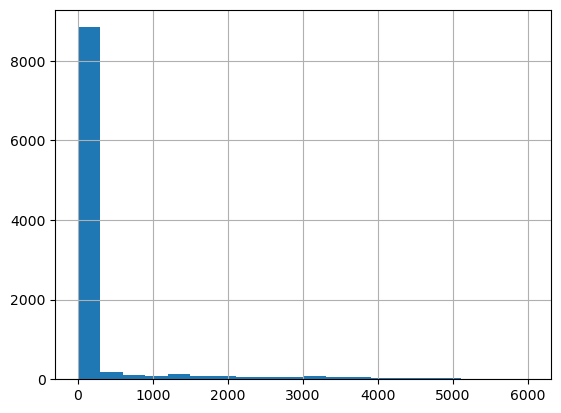

In [12]:
pd.DataFrame(df[ (df["ContinentOcean"]=="Northeast Atlantic Ocean") ])["MaxDepth"].hist(bins=20)

This shows in a very clear result that the overwhelming majority of samples within the northeast atlantic ocean has been gathered in under 300m of depth. To get a more clear answer it would be beneficial to zoom in to the data points in the lower depths to the left of the diagram. The visualization technique is useful to provide a bigger picture, but less useful to find out the spread in the lower depths.

How does the age of the sample relate to the max sample depth?

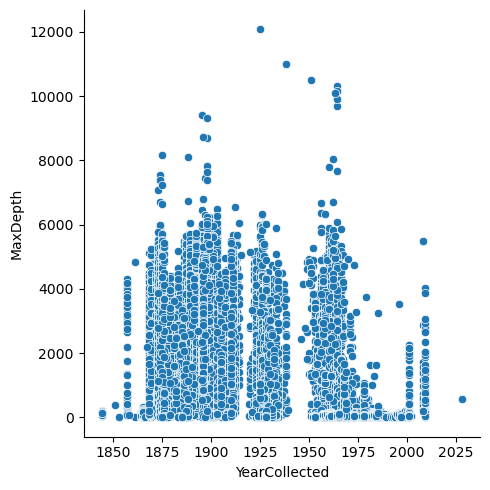

In [13]:
sns.relplot(data=df, x="YearCollected", y="MaxDepth")

This is a very interesting result which shows that not only have most samples from the very deep end of the spectrum been gathered a long time ago, it also shows that they often cluster around a few years. Another interesting observation is that not a lot of samples have been gathered in recent times. This visualization technique perfectly fits the question in my opinion.

How do the individual values of depth, collection year and location correlate with each other?

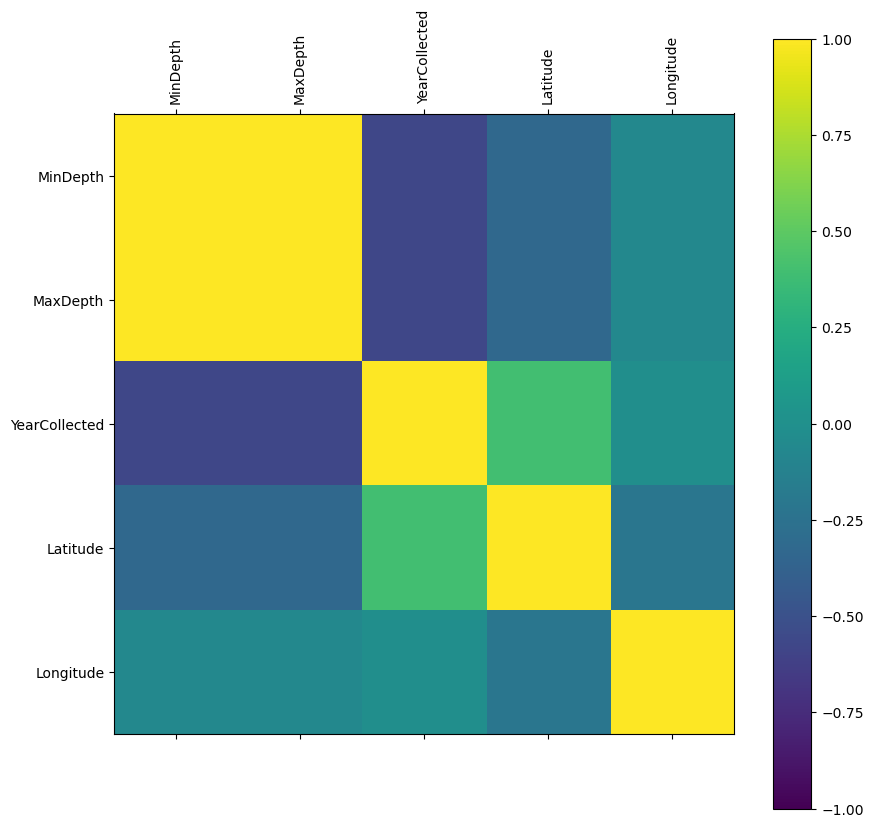

In [14]:
correlations = df.corr(method="pearson", numeric_only=True)
correlations
fig, ax = plt.subplots(figsize=(10,10))

# Defininig subplots is more flexible and allows
# deeper customization in matplotlib
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
axes_labels = df.columns.drop(["ContinentOcean", "SampleDesc", "WaterBody"])
plt.xticks(list(range(axes_labels.size)), axes_labels, rotation=90)
plt.yticks(list(range(axes_labels.size)), axes_labels)
plt.show()

I think this visualization technique perfectly captures the correlation of i.e. Min and Maxdepth and the negative correlation of YearCollected to the depths which is very interesting.

How has the maximum depth of water samples changed over time?


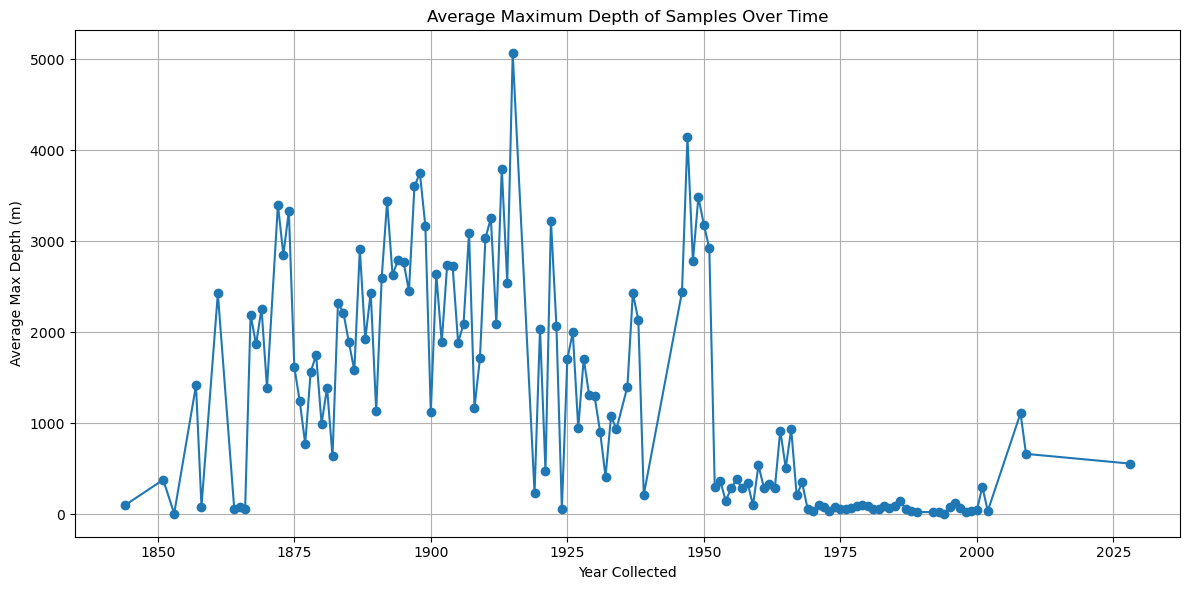

In [15]:
# Drop rows with missing values in relevant columns
df_filtered = df.dropna(subset=["YearCollected", "MaxDepth"])

# Group by year and calculate average maximum depth
depth_by_year = df_filtered.groupby("YearCollected")["MaxDepth"].mean().reset_index()

# Plotting
plt.figure(figsize=(12,6))
plt.plot(depth_by_year["YearCollected"], depth_by_year["MaxDepth"], marker='o')
plt.title("Average Maximum Depth of Samples Over Time")
plt.xlabel("Year Collected")
plt.ylabel("Average Max Depth (m)")
plt.grid(True)
plt.tight_layout()
plt.show()


This is an extremely interesting result, especially because it shows the increased sampling of low depths in recent times. this kind of visualization is perfectly suited to this kind of question.

Choose 2 numerical variables from your dataset and calculate the Pearson correlation. Describe the strength and direction of the correlation and reflect on the obtained results (30-50 words).


In [16]:
correlations = df.corr(method="pearson", numeric_only=True)
correlations

,MinDepth,MaxDepth,YearCollected,Latitude,Longitude
MinDepth,1.000000,0.999844,-0.574052,-0.326497,-0.063348
MaxDepth,0.999844,1.000000,-0.574485,-0.326862,-0.063294
YearCollected,-0.574052,-0.574485,1.000000,0.396954,-0.015371
Latitude,-0.326497,-0.326862,0.396954,1.000000,-0.218465
Longitude,-0.063348,-0.063294,-0.015371,-0.218465,1.000000


I choose to explain the correlation between MinDepth / MaxDepth and the one between YearCollected / Latitude

MinDepth / MaxDepth Shows an overwhelmingly positive correlation of 0.999844 which indicates that these values are extremely strongly correlated. This also makes a lot of sense, as the MinDepth and MaxDepth at the same location of a gathered sample must be very close to each other as it is the same location in a relatively small area.¨

YearCollected/Latitude is a less strong positive correlation whis is still relatively strong regarding the difference in datapoints. What we can read from it is, that the Latitude increases with the age of the sample. This means that younger samples are more likely to have been sampled in more local, more northern waters than the older samples which have generally been sampled all over the world.

## HW 3 Continuation

### Preparing the data for ML classification

The binary target class will be: "Is collected before the end of WW2 (1945)" -> IsCollectedBeforeEndWW2

3 variables as input features:
- Latitude
- Longitude
- MaxDepth

I chose Latitude, Longitude, and MaxDepth as input features because they tell us where a water sample was taken and how deep it was collected. These details might help us guess when the sample was taken. The target variable is whether the sample was collected before the end of World War II in 1945. I created this by checking if the year is before 1945 (yes = 1, no = 0). I will build a model that predicts if a sample was collected before 1945 using its location and depth.

In [17]:
df_filtered = df[["Latitude", "Longitude", "MaxDepth", "YearCollected"]]
print(df_filtered.dtypes)

Latitude         float64
Longitude        float64
MaxDepth         float64
YearCollected    float64
dtype: object


All of those types of the required columns are already numeric which is why I will not have to use ordinal or one-hot encoding.

#### Plotting Histogram of the Target class

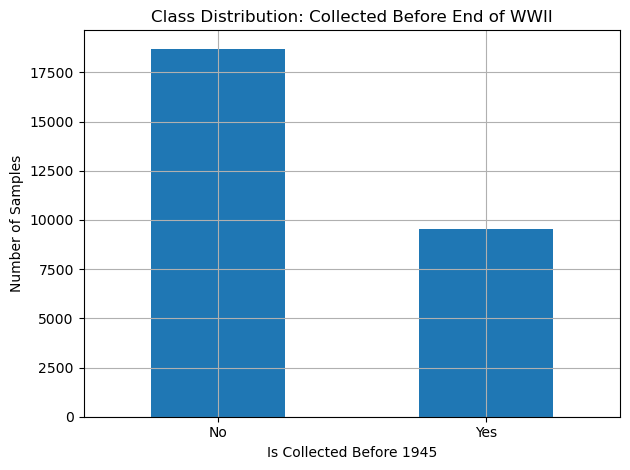

In [18]:
df["IsCollectedBeforeEndWW2"] = (df["YearCollected"] < 1945).astype(int)
df["IsCollectedBeforeEndWW2"].value_counts().plot(kind="bar")
plt.title("Class Distribution: Collected Before End of WWII")
plt.xlabel("Is Collected Before 1945")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

Class imbalance happens when one class has many more samples than the other. Most samples in the data were collected before 1945, so the model may learn to always predict that class. This can lead to poor accuracy on the smaller class and unfair or biased results.

In [19]:
df_filtered = df_filtered.dropna()

# Create binary target column
df_filtered["IsCollectedBeforeEndWW2"] = (df_filtered["YearCollected"] < 1945).astype(int)

# X, Y
X_val = df_filtered[["Latitude", "Longitude", "MaxDepth"]]
y_val = df_filtered["IsCollectedBeforeEndWW2"]


In [20]:
from sklearn.model_selection import train_test_split

# 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_val, y_val, test_size=0.2, stratify=y_val, random_state=42
)

Stratified partitioning ensures that the train and test sets maintain the same class distribution as the original dataset. This is important when classes are imbalanced, as it helps the model learn and evaluate both classes fairly, reducing bias toward the majority class.

### Evaluation

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

models = {
    # Decision Tree variants
    "DT1": DecisionTreeClassifier(max_depth=7),
    "DT3": DecisionTreeClassifier(max_depth=40),

    # Random Forest variants
    "RF1": RandomForestClassifier(n_estimators=5, max_depth=2),
    "RF2": RandomForestClassifier(n_estimators=300, max_depth=50),

    # KNN variants
    "KNN1": KNeighborsClassifier(n_neighbors=3),
    "KNN2": KNeighborsClassifier(n_neighbors=1),

    # SVM variants
    "SVM1": SVC(kernel='rbf', C=1.0),
    "SVM2": SVC(kernel='poly', C=0.3),

    # Logistic Regression variants
    "LR1": LogisticRegression(C=1.0, solver='liblinear'),
    "LR2": LogisticRegression(C=0.4, solver='liblinear'),
}

# Print classifier names and objects
for name, classifier in models.items():
    print("The name of the classifier is:", name, " and it is a sklearn object:", classifier)


The name of the classifier is: DT1  and it is a sklearn object: DecisionTreeClassifier(max_depth=7)
The name of the classifier is: DT3  and it is a sklearn object: DecisionTreeClassifier(max_depth=40)
The name of the classifier is: RF1  and it is a sklearn object: RandomForestClassifier(max_depth=2, n_estimators=5)
The name of the classifier is: RF2  and it is a sklearn object: RandomForestClassifier(max_depth=50, n_estimators=300)
The name of the classifier is: KNN1  and it is a sklearn object: KNeighborsClassifier(n_neighbors=3)
The name of the classifier is: KNN2  and it is a sklearn object: KNeighborsClassifier(n_neighbors=1)
The name of the classifier is: SVM1  and it is a sklearn object: SVC()
The name of the classifier is: SVM2  and it is a sklearn object: SVC(C=0.3, kernel='poly')
The name of the classifier is: LR1  and it is a sklearn object: LogisticRegression(solver='liblinear')
The name of the classifier is: LR2  and it is a sklearn object: LogisticRegression(C=0.4, solver=

In [22]:
results = pd.DataFrame({
                        "classifier_name": [],
                        "training_time": [],
                        "prediction_time": [],
                        "accuracy": [],
                        "precision": [],
                        "recall": [],
                        "f1": []
                        })
results

,classifier_name,training_time,prediction_time,accuracy,precision,recall,f1


In [23]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Apply the classifier in each dataset
for name, classifier in models.items():

    # Start measuring the training time
    t_start = time.time()
    # The code below applies the specific classifier from the loop on the data
    classifier.fit(X_train,y_train)
    # Stop measuring training time
    t_end = time.time()
    # Calculate Variable of interest `training_time`
    training_time = t_end - t_start
    #######

    # Start measuring the prediction time
    t_start = time.time()
    # Predict on test set
    y_predicted = classifier.predict(X_test)
    # Stop measuring prediction time
    t_end = time.time()
    # Calculate Variable of interest `prediction_time`
    prediction_time = t_end - t_start
    #######


    # Get performance metrics
    accuracy_result = accuracy_score(y_test, y_predicted)
    precision_result = precision_score(y_test, y_predicted)
    recall_result = recall_score(y_test, y_predicted)
    f1_result = f1_score(y_test, y_predicted)
    #######


    #### Generate the results to populate the pandas.DataFrame
    this_result = pd.DataFrame({
                    "classifier_name": [name],
                    "training_time": [training_time],
                    "prediction_time": [prediction_time],
                    "accuracy": [accuracy_result],
                    "precision": [precision_result],
                    "recall": [recall_result],
                    "f1": [f1_result]
                    })

    # Append to the main dataframe with the results
    results = pd.concat([results, this_result], axis=0, ignore_index=True)

    results

After a lot of tweaking and testing of hyperparameters:

In [24]:
results

,classifier_name,training_time,prediction_time,accuracy,precision,recall,f1
0,DT1,0.043080,0.001002,0.937389,0.910992,0.918875,0.914917
1,DT3,0.065912,0.000992,0.954825,0.944597,0.931314,0.937908
2,RF1,0.025992,0.002000,0.896176,0.853333,0.865333,0.859291
3,RF2,5.661671,0.146427,0.964137,0.945513,0.957274,0.951357
4,KNN1,0.009007,0.149255,0.939370,0.907985,0.928610,0.918182
5,KNN2,0.008996,0.133135,0.933030,0.912166,0.904273,0.908202
6,SVM1,5.647940,1.859989,0.888052,0.876319,0.808545,0.841069
7,SVM2,6.923322,0.882833,0.766990,0.903962,0.407247,0.561521
8,LR1,0.026973,0.001011,0.856747,0.872848,0.712818,0.784757
9,LR2,0.026999,0.001005,0.856747,0.872848,0.712818,0.784757


The SVM Variants were always extremely imperformant and low accuracy. I found some better-accuracy configurations with linear kernel, but it then took over 20min to run it once.

### Testing on Test-Dataset

In [25]:
results = pd.DataFrame({
                        "classifier_name": [],
                        "training_time": [],
                        "prediction_time": [],
                        "accuracy": [],
                        "precision": [],
                        "recall": [],
                        "f1": []
                        })
results

import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Apply the classifier in each dataset
for name, classifier in models.items():

    # Start measuring the training time
    t_start = time.time()
    # The code below applies the specific classifier from the loop on the data
    classifier.fit(X_train,y_train)
    # Stop measuring training time
    t_end = time.time()
    # Calculate Variable of interest `training_time`
    training_time = t_end - t_start
    #######

    # Start measuring the prediction time
    t_start = time.time()
    # Predict on test set
    y_predicted = classifier.predict(X_val)
    # Stop measuring prediction time
    t_end = time.time()
    # Calculate Variable of interest `prediction_time`
    prediction_time = t_end - t_start
    #######


    # Get performance metrics
    accuracy_result = accuracy_score(y_val, y_predicted)
    precision_result = precision_score(y_val, y_predicted)
    recall_result = recall_score(y_val, y_predicted)
    f1_result = f1_score(y_val, y_predicted)
    #######


    #### Generate the results to populate the pandas.DataFrame
    this_result = pd.DataFrame({
                    "classifier_name": [name],
                    "training_time": [training_time],
                    "prediction_time": [prediction_time],
                    "accuracy": [accuracy_result],
                    "precision": [precision_result],
                    "recall": [recall_result],
                    "f1": [f1_result]
                    })

    # Append to the main dataframe with the results
    results = pd.concat([results, this_result], axis=0, ignore_index=True)

Results on test data:

In [26]:
results

,classifier_name,training_time,prediction_time,accuracy,precision,recall,f1
0,DT1,0.042109,0.001975,0.942654,0.911625,0.934011,0.922682
1,DT3,0.063685,0.001995,0.990172,0.989126,0.983990,0.986551
2,RF1,0.023001,0.003004,0.902945,0.861937,0.875270,0.868552
3,RF2,5.222781,0.516630,0.992193,0.988025,0.990697,0.989359
4,KNN1,0.009989,0.727909,0.955891,0.929439,0.951861,0.940516
5,KNN2,0.009085,0.648577,0.986129,0.982112,0.979987,0.981048
6,SVM1,5.626286,9.351357,0.883327,0.869025,0.802466,0.834421
7,SVM2,7.157047,4.459306,0.765268,0.896585,0.406101,0.559005
8,LR1,0.022995,0.001917,0.852455,0.871284,0.700779,0.776785
9,LR2,0.030646,0.001000,0.852495,0.871302,0.700887,0.776859


### Reflection

##### 1. Which classifier provides the best balance between high accuracy and fast prediction time?

RF2 achieves the highest accuracy (99.2%) but has a longer prediction time. In contrast, DT3 offers almost equal accuracy (99.0%) with much faster prediction, making it more efficient overall. The time used for RF2 is still very reasonable though compared to the SVM Variants, those are extremely costly and don't offer an improvement in performance.

##### 2. How does increasing complexity in models like RF and KNN affect training and prediction time?

RF2 and KNN2 show improved performance over RF1 and KNN1 but significantly higher computation time, especially during prediction—highlighting a trade-off between performance and speed.

##### 3. Are there models with good precision but weak recall, and what does that imply?

LR1 and LR2 show decent precision (~87%) but low recall (~70%), suggesting they miss many true positives—making them less suitable when recall is crucial.

##### Which classification model seems to perform better in your data?  Would you deploy it in a real-life task? Why or why not? (30-50 words)


The best-performing model is RF2, with the highest accuracy and F1-score. While it's computationally heavy, its predictive power is excellent. I would consider deploying it in a real-life task if the application can tolerate slower prediction times in exchange for high reliability and accuracy. To me personally it was mind-blowing how accurate these models are. I didn't expect the models to be this accurate in general.